In [91]:
import os
import sys
current_dir = os.path.dirname(os.getcwd())
if not current_dir in sys.path:
    sys.path.append(current_dir)

# ----------------------------------------------------

In [92]:
import math
import torch
import numpy as np
import phantom as pt
import IR_UTE as ute
import torchkbnufft as tkbn
import matplotlib.pyplot as plt

# create phantom
img_size = 256
inner_size = 80
mixed_size = 160
upper_square_size = 20
outer_size = 190

# values in seconds
t1_wm = 0.8         
t2_wm = 0.08
t1_myelin = 0.226         
t2_myelin = 300 * 1e-6

# Time Step
dt = 10 # unite: us

# Off-resonance frequencies
df = np.linspace(-500, 500, 200)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Create Virtual Phantom

### (1) White Matter (T1 map, T2 map, Probability map)

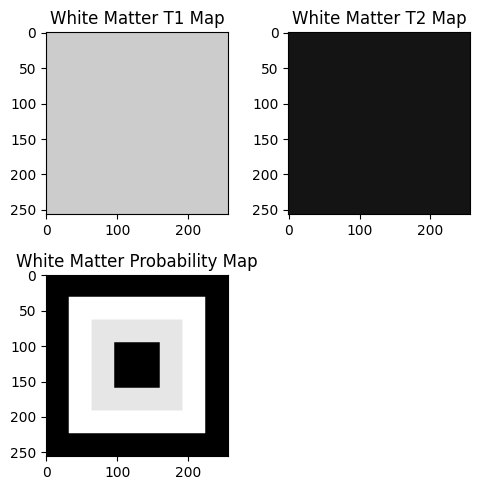

In [93]:
inner_wm = 0
mixed_wm = 0.9
outer_wm = 1

wm = pt.VirtualPhantom(img_size)
t1_map_mw, t2_map_mw, prob_map_myelin = wm.create_maps(t1_wm, t2_wm, inner_wm, mixed_wm, outer_wm, upper_sqaure = True)
wm.phantom_display('White Matter')

### (2) Myelin (T1 map, T2 map, Probability map)

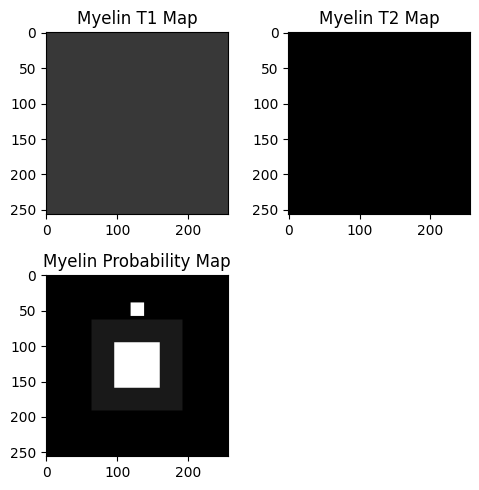

In [94]:
inner_myelin = 1
mixed_myelin = 0.1
outer_myelin = 0

myelin = pt.VirtualPhantom(img_size)
t1_map_myelin, t2_map_myelin, prob_map_myelin = myelin.create_maps(t1_myelin, t2_myelin, inner_myelin, mixed_myelin, outer_myelin, upper_sqaure=True)
myelin.phantom_display('Myelin')

## 2. IR-UTE Simulation

In [98]:
n_readout = 4
t_readout = 0.768 * 1e-3
myelin = ute.IR_UTE(dt, df, t1_myelin, t2_myelin)


t_nullout = int(0.55 * 1e6)
m_ir = myelin.inversion_recovery()

print(t_nullout)
flip_angle = torch.pi / 4
m, excitation_time, mag_readout_start, t_mag_readout_start = myelin.transverse_excitation(n_readout, t_readout, t_nullout, flip_angle)


550000
t_readout_end_index: 201
write_start: 0
[-7.41098469e-323 -7.41098469e-323  9.05858697e-001]
write_start: 201
[-5.21375521e-05  1.89035523e-03  7.03830547e-01]
write_start: 402
[-4.06360211e-05  1.47065274e-03  5.48167866e-01]
write_start: 603
[-3.16642354e-05  1.14596640e-03  4.28846082e-01]


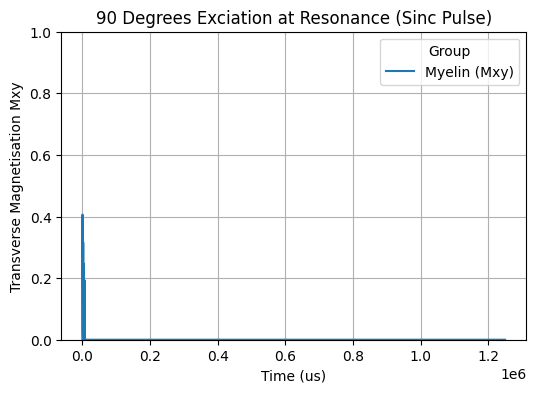

In [96]:
magnetisation_myelin_rf_sinc = m
n_steps =  magnetisation_myelin_rf_sinc.shape[1]

time = np.arange(n_steps) * dt  # micro seconds


magnetisation_myelin_rf_total_xy = np.sqrt(np.power(magnetisation_myelin_rf_sinc[100, :, 0], 2) + np.power(magnetisation_myelin_rf_sinc[100, :, 1], 2))

plt.figure(figsize=(6,4))
plt.plot(time, magnetisation_myelin_rf_total_xy, label='Myelin (Mxy)')



plt.xlabel('Time (us)')
plt.ylabel('Transverse Magnetisation Mxy')
plt.ylim([0,1])
plt.title('90 Degrees Exciation at Resonance (Sinc Pulse)')
plt.grid(True)
plt.legend(title = "Group")
plt.show()

(256, 810)


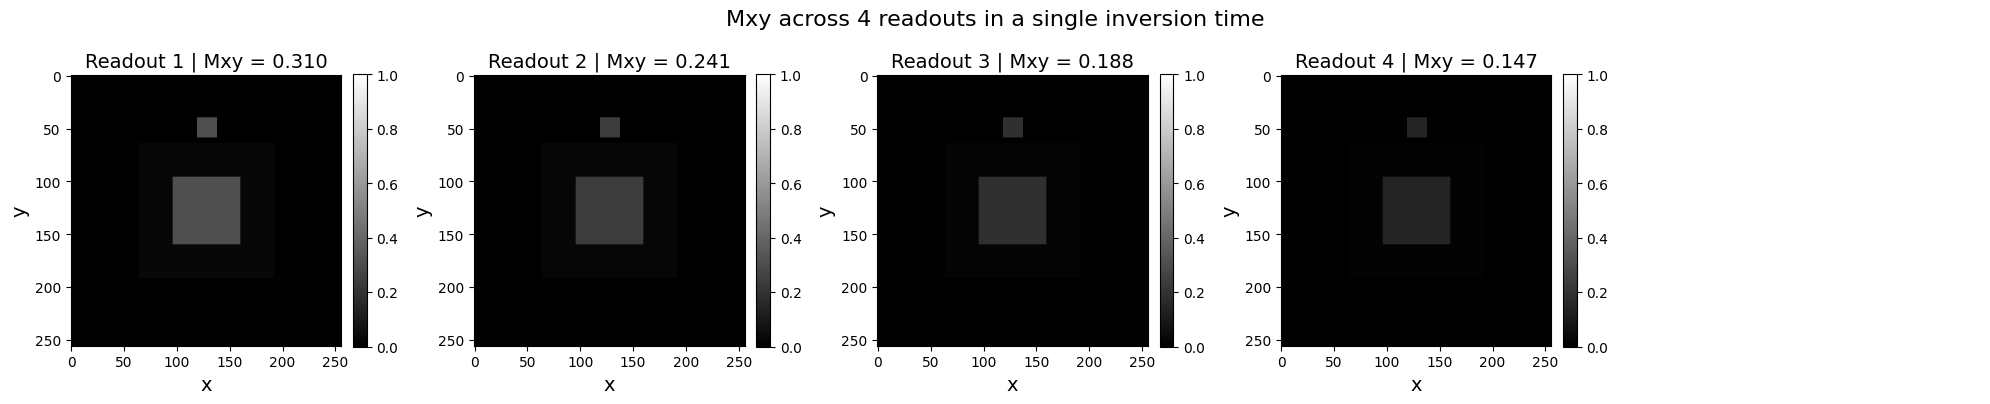

(256, 810)
[-0.00106077  0.31017577  0.7018187 ]


IndexError: arrays used as indices must be of integer (or boolean) type

In [99]:
class RadialSampling():
    def __init__(self, img_size):
        self.img_size = img_size
        self.spokelength = self.img_size
        self.grid_size = (self.spokelength, self.spokelength)
        self.nspokes = int(np.ceil(self.spokelength * math.pi) + 5)
        pass

    def kx_ky_coordinates(self):
        ga = np.deg2rad(180 / ((1 + np.sqrt(5)) / 2))
        kx = np.zeros(shape=(self.spokelength, self.nspokes))
        print(kx.shape)
        ky = np.zeros(shape=(self.spokelength, self.nspokes))
        ky[:, 0] = np.linspace(0, np.pi, self.spokelength)
        for i in range(1, self.nspokes):
            kx[:, i] = np.cos(ga) * kx[:, i - 1] - np.sin(ga) * ky[:, i - 1]
            ky[:, i] = np.sin(ga) * kx[:, i - 1] + np.cos(ga) * ky[:, i - 1]
            
        self.ky = np.transpose(ky)
        self.kx = np.transpose(kx)

   
       

        
    def xxx(self, mag_readout_start, df, prob_map, n_readout):
        self.kx_ky_coordinates()
        self.n_on_resonance = int(len(df) / 2)

        sampled_signals = []
        total_num = np.ceil(self.nspokes/n_readout)
        while total_num > 0:
            if total_num == 1:
                n = total_num
            else:
                n = n_readout
            
            for mag in mag_readout_start:
                print(mag)
                magnetisation_xy = np.sqrt(mag[0]**2 + mag[1]**2)
                signal = np.full((self.img_size, self.img_size), magnetisation_xy, dtype=np.float64)
                signal_weighted = signal * prob_map
                sampled_signals = signal_weighted[self.ky[0, :], self.kx[0, :]]
                print(sampled_signals)

            





           
    


    def visualReadoutsInSingleTI(self, mag_readout_start, df, prob_map):
        self.kx_ky_coordinates()
        self.n_on_resonance = int(len(df) / 2)
        n = len(mag_readout_start)

        ncols = 5
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(4 * ncols, 4 * nrows)
        )

        axes = np.array(axes).ravel()
        for i, mag in enumerate(mag_readout_start):
            magnetisation_xy = np.sqrt(mag[0]**2 + mag[1]**2)
            signal = np.full(
                (self.img_size, self.img_size),
                magnetisation_xy,
                dtype=np.float64
            )
            signal_weighted = signal * prob_map

            # plot single graph
            ax = axes[i]
            im = ax.imshow(
                signal_weighted,
                cmap='gray',
                vmin=0,
                vmax=1
            )
            ax.set_title(f"Readout {i+1} | Mxy = {magnetisation_xy:.3f}", fontsize=14)
            ax.set_xlabel("x", fontsize=14)
            ax.set_ylabel("y", fontsize=14)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # close all empty subplots
        for j in range(len(mag_readout_start), len(axes)):
            axes[j].axis("off")

        plt.suptitle(f"Mxy across {n} readouts in a single inversion time", fontsize = 16)
        plt.tight_layout()
        plt.show()


    

img_size = 256
radial_sampling = RadialSampling(img_size)
radial_sampling.visualReadoutsInSingleTI(mag_readout_start, df, prob_map_myelin)
radial_sampling.xxx(mag_readout_start, df, prob_map_myelin, n_readout)




(256, 810)
total num: 203
torch.Size([1, 1, 207360])
tensor([[[ 1.3722e+03-2.1233e-14j,  1.2712e+03+7.8280e+01j,
           1.0194e+03+9.5018e+01j,  7.3033e+02+3.4565e+01j,
           5.0106e+02-4.3408e+01j,  3.5605e+02-7.0843e+01j,
           2.5282e+02-2.7723e+01j,  1.3815e+02+4.1983e+01j,
           3.7564e+00+7.4807e+01j, -1.1470e+02+4.1514e+01j,
          -1.7710e+02-2.7526e+01j, -1.7801e+02-7.2967e+01j,
          -1.4973e+02-6.2228e+01j, -1.2877e+02-1.1343e+01j,
          -1.1966e+02+3.2988e+01j, -9.7708e+01+3.6471e+01j,
          -3.9820e+01+6.7318e+00j,  4.6798e+01-2.1313e+01j,
           1.2452e+02-2.1240e+01j,  1.5517e+02+4.0701e+00j,
           1.3171e+02+2.9270e+01j,  7.9407e+01+3.3226e+01j,
           3.2371e+01+1.6821e+01j,  7.3562e+00-2.1859e+00j,
          -3.7742e+00-1.0251e+01j, -1.8024e+01-8.3281e+00j,
          -4.1228e+01-6.8029e+00j, -6.5052e+01-1.1599e+01j,
          -7.7371e+01-1.7399e+01j, -7.3683e+01-1.5255e+01j,
          -5.8415e+01-5.2310e+00j, -3.6760e+01+

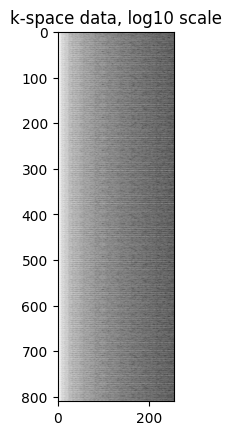

In [118]:
class RadialSampling():
    def __init__(self, img_size):
        self.img_size = img_size
        self.spokelength = self.img_size
        self.grid_size = (self.spokelength, self.spokelength)
        self.nspokes = int(np.ceil(self.spokelength * math.pi) + 5)
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.nufft_ob = tkbn.KbNufft(im_size=(img_size, img_size), grid_size= self.grid_size).to(self.device)
        self.adjnufft_ob = tkbn.KbNufftAdjoint(im_size=(img_size, img_size), grid_size=self.grid_size).to(self.device)
        pass

    def kx_ky_coordinates(self):
        ga = np.deg2rad(180 / ((1 + np.sqrt(5)) / 2))
        kx = np.zeros(shape=(self.spokelength, self.nspokes))
        print(kx.shape)
        ky = np.zeros(shape=(self.spokelength, self.nspokes))
        ky[:, 0] = np.linspace(0, np.pi, self.spokelength)
        for i in range(1, self.nspokes):
            kx[:, i] = np.cos(ga) * kx[:, i - 1] - np.sin(ga) * ky[:, i - 1]
            ky[:, i] = np.sin(ga) * kx[:, i - 1] + np.cos(ga) * ky[:, i - 1]
            
        self.ky = np.transpose(ky)
        self.kx = np.transpose(kx)
    

        

        
    def xxx(self, mag_readout_start, df, prob_map, n_readout, t2):
        self.kx_ky_coordinates()
        self.n_on_resonance = int(len(df) / 2)

       
        kdata_total = []
        #kdata_total = torch.empty(1, 1, self.nspokes * self.spokelength)
        total_num = int(np.ceil(self.nspokes/n_readout))
        print('total num:', total_num)
        groups = [list(range(i, min(i+n_readout, self.nspokes))) for i in range(0, self.nspokes, n_readout)]

        for i in range(total_num):
            gp = groups[i]
            #print(gp)
            for j, mag in enumerate(mag_readout_start):
                if j >= len(gp):
                    break
                magnetisation_xy = np.sqrt(mag[0]**2 + mag[1]**2)
                signal = np.full((self.img_size, self.img_size), magnetisation_xy, dtype=np.float64)
                signal_weighted = signal * prob_map

               
                #print(gp[j])
                ky = self.ky[gp[j], :]
                kx = self.kx[gp[j], :]
                ktraj = np.stack((ky.flatten(), kx.flatten()), axis=0)
                
                signal_weighted = torch.as_tensor(signal_weighted, device=device).to(torch.complex128)    
                if signal_weighted.ndim == 2:
                    signal_weighted = signal_weighted[None, None, ...] 
                ktraj = torch.as_tensor(ktraj, device=device).to(torch.float64)

                with torch.no_grad():                            # forward (turn off gradient when no need, save memory)
                    kdata = self.nufft_ob(signal_weighted, ktraj)
          
                #torch.cat([kdata_total, kdata], dim=2)
                kdata_total.append(kdata)
        kdata_total = torch.cat(kdata_total, dim=2)

        print(kdata_total.shape)
        print(kdata)
        t = np.linspace(0,0.001, self.spokelength)
        kdata_numpy = np.reshape(kdata_total.cpu().numpy(), (self.nspokes, self.spokelength)) * np.exp(-t/t2)
        plt.imshow(np.log10(np.absolute(kdata_numpy)))
        plt.gray()
        plt.title('k-space data, log10 scale')
        plt.show()
       

        
    

img_size = 256
n_readout = 4
t2 = t2_myelin
radial_sampling = RadialSampling(img_size)
radial_sampling.xxx(mag_readout_start, df, prob_map_myelin, n_readout, t2)

(256, 810)
total num: 203
torch.Size([2, 207360])
torch.Size([1, 1, 207360])
torch.Size([1, 1, 207360])
torch.Size([1, 1, 207360])
[[3669717.87650461 3468245.31704007 3290353.04859234 ... 3291049.06164168
  3468681.36948007 3669867.84837884]
 [3470317.41265904 3279876.19755023 3111722.30073898 ... 3111973.02602583
  3280012.64505348 3470359.30280093]
 [3294200.65673825 3113499.22219136 2953964.71767628 ... 2953887.64485547
  3113432.88834321 3294174.77906572]
 ...
 [3284861.82242271 3104256.23973926 2944852.59865793 ... 2946641.83987853
  3105467.72644944 3285304.43086377]
 [3464367.6989168  3273957.69246716 3105890.80145181 ... 3107455.67779241
  3275027.62509335 3464761.91137395]
 [3667609.71889159 3466139.95214353 3288282.36104094 ... 3289464.37724984
  3466931.33770592 3667896.20136531]]


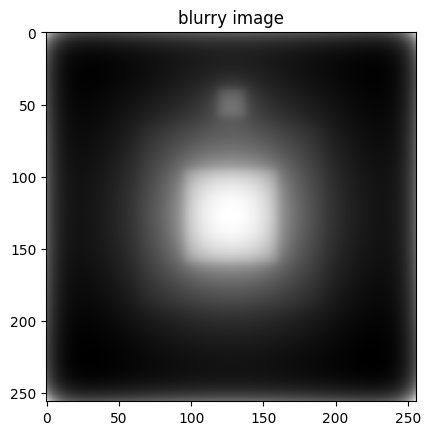

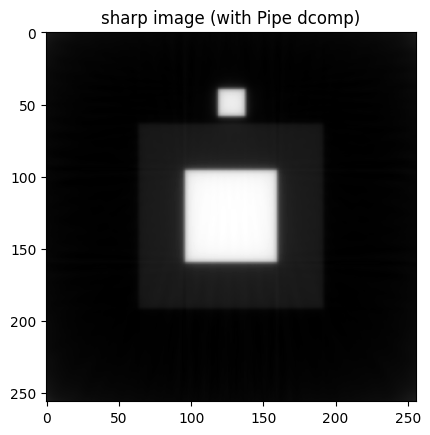

In [135]:
class RadialSampling():
    def __init__(self, img_size):
        self.img_size = img_size
        self.spokelength = self.img_size
        self.grid_size = (self.spokelength, self.spokelength)
        self.nspokes = int(np.ceil(self.spokelength * math.pi) + 5)
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.nufft_ob = tkbn.KbNufft(im_size=(img_size, img_size), grid_size= self.grid_size).to(self.device)
        self.adjnufft_ob = tkbn.KbNufftAdjoint(im_size=(img_size, img_size), grid_size=self.grid_size).to(self.device)
        pass

    def kx_ky_coordinates(self):
        ga = np.deg2rad(180 / ((1 + np.sqrt(5)) / 2))
        kx = np.zeros(shape=(self.spokelength, self.nspokes))
        print(kx.shape)
        ky = np.zeros(shape=(self.spokelength, self.nspokes))
        ky[:, 0] = np.linspace(0, np.pi, self.spokelength)
        for i in range(1, self.nspokes):
            kx[:, i] = np.cos(ga) * kx[:, i - 1] - np.sin(ga) * ky[:, i - 1]
            ky[:, i] = np.sin(ga) * kx[:, i - 1] + np.cos(ga) * ky[:, i - 1]
            
        self.ky = np.transpose(ky)
        self.kx = np.transpose(kx)
    

        

        
    def xxx(self, mag_readout_start, df, prob_map, n_readout, t2):
        self.kx_ky_coordinates()
        self.n_on_resonance = int(len(df) / 2)

       
        kdata_total, ktraj_total = [], []
        #kdata_total = torch.empty(1, 1, self.nspokes * self.spokelength)
        total_num = int(np.ceil(self.nspokes/n_readout))
        print('total num:', total_num)
        groups = [list(range(i, min(i+n_readout, self.nspokes))) for i in range(0, self.nspokes, n_readout)]

        for i in range(total_num):
            gp = groups[i]
            #print(gp)
            for j, mag in enumerate(mag_readout_start):
                if j >= len(gp):
                    break
                magnetisation_xy = np.sqrt(mag[0]**2 + mag[1]**2)
                signal = np.full((self.img_size, self.img_size), magnetisation_xy, dtype=np.float64)
                signal_weighted = signal * prob_map

               
                #print(gp[j])
                ky = self.ky[gp[j], :]
                kx = self.kx[gp[j], :]
                ktraj = np.stack((ky.flatten(), kx.flatten()), axis=0)
                ktraj_total.append(ktraj)
                signal_weighted = torch.as_tensor(signal_weighted, device=device).to(torch.complex128)    
                if signal_weighted.ndim == 2:
                    signal_weighted = signal_weighted[None, None, ...] 
                ktraj = torch.as_tensor(ktraj, device=device).to(torch.float64)

                with torch.no_grad():                            # forward (turn off gradient when no need, save memory)
                    kdata = self.nufft_ob(signal_weighted, ktraj)
          
                #torch.cat([kdata_total, kdata], dim=2)
                kdata_total.append(kdata)
        
        kdata_total = torch.cat(kdata_total, dim=2)
        ktraj_total = [torch.as_tensor(x, device=self.device).to(torch.float64) for x in ktraj_total]
        ktraj_total = torch.cat(ktraj_total, dim=1)
        
        print(ktraj_total.shape)
        print(kdata_total.shape)
        t = np.linspace(0,0.001, self.spokelength)
        kdata_numpy = np.reshape(kdata_total.cpu().numpy(), (self.nspokes, self.spokelength)) * np.exp(-t/t2)
        kdata_t = torch.from_numpy(kdata_numpy).to(torch.complex128).reshape(1, 1, -1)
        print(kdata_t.shape)

        # method 1: no density compensation (blurry image)
        
        image_blurry = self.adjnufft_ob(kdata_t, ktraj_total)

        # method 2: use density compensation
        dcomp = tkbn.calc_density_compensation_function(ktraj=ktraj_total, im_size=(img_size,img_size))
        print(dcomp.shape)
        image_sharp = self.adjnufft_ob(kdata_t * dcomp, ktraj_total)
        # show the images
        image_blurry_numpy = np.squeeze(image_blurry.cpu().numpy())
        image_sharp_numpy = np.squeeze(image_sharp.cpu().numpy())

        plt.figure(0)
        plt.imshow(np.absolute(image_blurry_numpy))
        print(np.absolute(image_blurry_numpy))
        plt.gray()
        plt.title('blurry image')

        plt.figure(1)
        plt.imshow(np.absolute(image_sharp_numpy))
        plt.gray()
        plt.title('sharp image (with Pipe dcomp)')

        plt.show()

    def visual(self, kdata, t2):
        t = np.linspace(0,0.001, self.spokelength)
        kdata_numpy = np.reshape(kdata.cpu().numpy(), (self.nspokes, self.spokelength)) * np.exp(-t/t2)
        plt.imshow(np.log10(np.absolute(kdata_numpy)))
        plt.gray()
        plt.title('k-space data, log10 scale')
        plt.show()
       

        
    

img_size = 256
n_readout = 4
t2 = t2_myelin
radial_sampling = RadialSampling(img_size)
radial_sampling.xxx(mag_readout_start, df, prob_map_myelin, n_readout, t2)

In [ ]:
groups = [list(range(i, min(i+5, 256))) for i in range(0, 256, 5)]
print(groups)
groups = []
for i in range(0, 256, 5):
    group = list(range(i, min(i+5, 256)))
    groups.append(group)
print(groups)

[[0, 1, 2, 3, 4], [5, 6, 7, 8, 9], [10, 11, 12, 13, 14], [15, 16, 17, 18, 19], [20, 21, 22, 23, 24], [25, 26, 27, 28, 29], [30, 31, 32, 33, 34], [35, 36, 37, 38, 39], [40, 41, 42, 43, 44], [45, 46, 47, 48, 49], [50, 51, 52, 53, 54], [55, 56, 57, 58, 59], [60, 61, 62, 63, 64], [65, 66, 67, 68, 69], [70, 71, 72, 73, 74], [75, 76, 77, 78, 79], [80, 81, 82, 83, 84], [85, 86, 87, 88, 89], [90, 91, 92, 93, 94], [95, 96, 97, 98, 99], [100, 101, 102, 103, 104], [105, 106, 107, 108, 109], [110, 111, 112, 113, 114], [115, 116, 117, 118, 119], [120, 121, 122, 123, 124], [125, 126, 127, 128, 129], [130, 131, 132, 133, 134], [135, 136, 137, 138, 139], [140, 141, 142, 143, 144], [145, 146, 147, 148, 149], [150, 151, 152, 153, 154], [155, 156, 157, 158, 159], [160, 161, 162, 163, 164], [165, 166, 167, 168, 169], [170, 171, 172, 173, 174], [175, 176, 177, 178, 179], [180, 181, 182, 183, 184], [185, 186, 187, 188, 189], [190, 191, 192, 193, 194], [195, 196, 197, 198, 199], [200, 201, 202, 203, 204], [2